In [6]:
import pandas as pd
from feature_extraction import process_json_file
from ehda_normalization import prepare_training_data

df = process_json_file(r"C:\Users\HV\Desktop\bruno_work\main\data\Ethanol\Current\experiment_0.json")              # or process_multiple_files()
df = df[df['label'] != 'EXCLUDE'].copy()
df = df[df['label'] != 'unconclusive'].copy()


  [experiment_0.json]  sample 0  (id=1, mode=cone_jet)  [1/102]
  [experiment_0.json]  sample 1  (id=2, mode=cone_jet)  [2/102]
  [experiment_0.json]  sample 2  (id=3, mode=dripping)  [3/102]
  [experiment_0.json]  sample 3  (id=4, mode=unconclusive)  [4/102]
  [experiment_0.json]  sample 4  (id=5, mode=unconclusive)  [5/102]
  [experiment_0.json]  sample 5  (id=6, mode=unconclusive)  [6/102]
  [experiment_0.json]  sample 6  (id=7, mode=unconclusive)  [7/102]
  [experiment_0.json]  sample 7  (id=8, mode=unconclusive)  [8/102]
  [experiment_0.json]  sample 8  (id=9, mode=unconclusive)  [9/102]
  [experiment_0.json]  sample 9  (id=10, mode=unconclusive)  [10/102]
  [experiment_0.json]  sample 10  (id=11, mode=intermitent)  [11/102]
  [experiment_0.json]  sample 11  (id=12, mode=unconclusive)  [12/102]
  [experiment_0.json]  sample 12  (id=13, mode=intermitent)  [13/102]
  [experiment_0.json]  sample 13  (id=14, mode=intermitent)  [14/102]
  [experiment_0.json]  sample 14  (id=15, mode=un

In [7]:
# only to help reason on choices for normalization

# Define non-feature columns
non_features = ['sample_id', 'label', 'timestamp', 'source_file']

# Select feature columns
feature_cols = [c for c in df.columns if c not in non_features]

# Compute percentiles
percentiles = [0.05, 0.25, 0.50, 0.75, 0.95]
percentile_df = df[feature_cols].quantile(percentiles)

# Rename index for readability
percentile_df.index = ['p5', 'p25', 'p50', 'p75', 'p95']

# To temporarily print all values
with pd.option_context(
    'display.max_rows', None,
    'display.max_columns', None,
    'display.width', None,
    'display.float_format', lambda x: '%.3f' % x
):
    print(percentile_df.T)  # transpose for nicer view

                                   p5            p25              p50  \
target_voltage               3460.000       7100.000         9500.000   
actual_voltage               3460.602       7100.382         9500.160   
voltage_error                  -0.200         -0.100            0.150   
flow_rate                       1.000          1.000            1.000   
current_PS                      0.000          0.000            0.000   
mean                            1.540        155.575         1937.956   
std                            19.927         40.662          396.230   
median                          2.231        152.454         1836.886   
rms                            28.442        160.980         2022.380   
variance                      397.086       1746.157       157014.734   
peak                          110.560        296.232         3041.646   
crest_factor                    1.155          1.261            1.450   
kurtosis                       -1.484         -1.18

In [8]:
from sklearn.preprocessing import RobustScaler
import numpy as np

# parts of the df that are not features
drop_features = [
    'sample_id', 'label', 'timestamp', 'source_file'
]
# define feature groups for targeted normalization
linear_features = [
    'target_voltage', 'actual_voltage', 'flow_rate', 'dominant_freq'
]
log_robust_features = [
    # energy / power
    'total_power', 'wavelet_total_energy',
    'wt_approx_L6_energy',
    'wt_detail_L6_energy', 'wt_detail_L5_energy',
    'wt_detail_L4_energy', 'wt_detail_L3_energy',
    'wt_detail_L2_energy', 'wt_detail_L1_energy',

    # frequency
    'mean_freq', 'median_freq',
    'spectral_rolloff', 'spectral_bandwidth',

    # derivatives
    'derivative_variance'
]
robust_features = [
    'voltage_error',
    'median', 'iqr',
    'derivative_mean_abs',
    'zero_crossing_rate',
    'shape_factor',
    'skewness', 'kurtosis',
    'peak', 'peak_to_peak', 'crest_factor'
]
passthrough_features = [c for c in df.columns if c.endswith('_rel')]
low_variance_features = [
    'std', 'rms', 'variance',
    'mean', 'current_PS'
]

# apply normalizations

df_scaled = df.copy()

# --- LINEAR SCALING (physical features) ---
# scaler_linear = MinMaxScaler()
# df_scaled[linear_features] = scaler_linear.fit_transform(df[linear_features])

# "improved" way of treating linear features that have meaning
linear_scale_factors = {
    'target_voltage': 10000.0,
    'actual_voltage': 10000.0,
    'flow_rate': 50.0,
    'dominant_freq': 100.0,
}
for col, factor in linear_scale_factors.items():
    df_scaled[col] = df[col] / factor

# --- LOG + ROBUST (heavy-tailed features) ---
def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))

df_scaled[log_robust_features] = signed_log1p(df[log_robust_features])
df_scaled[log_robust_features] = RobustScaler().fit_transform(df_scaled[log_robust_features])


# --- ROBUST ONLY ---
df_scaled[robust_features] = RobustScaler().fit_transform(df[robust_features])


# --- PASSTHROUGH ---
# leave as-is (or optional light scaling)


# --- FINAL FEATURE MATRIX ---
feature_cols = [
    c for c in df.columns if c not in drop_features
]

X_scaled = df_scaled[feature_cols].values

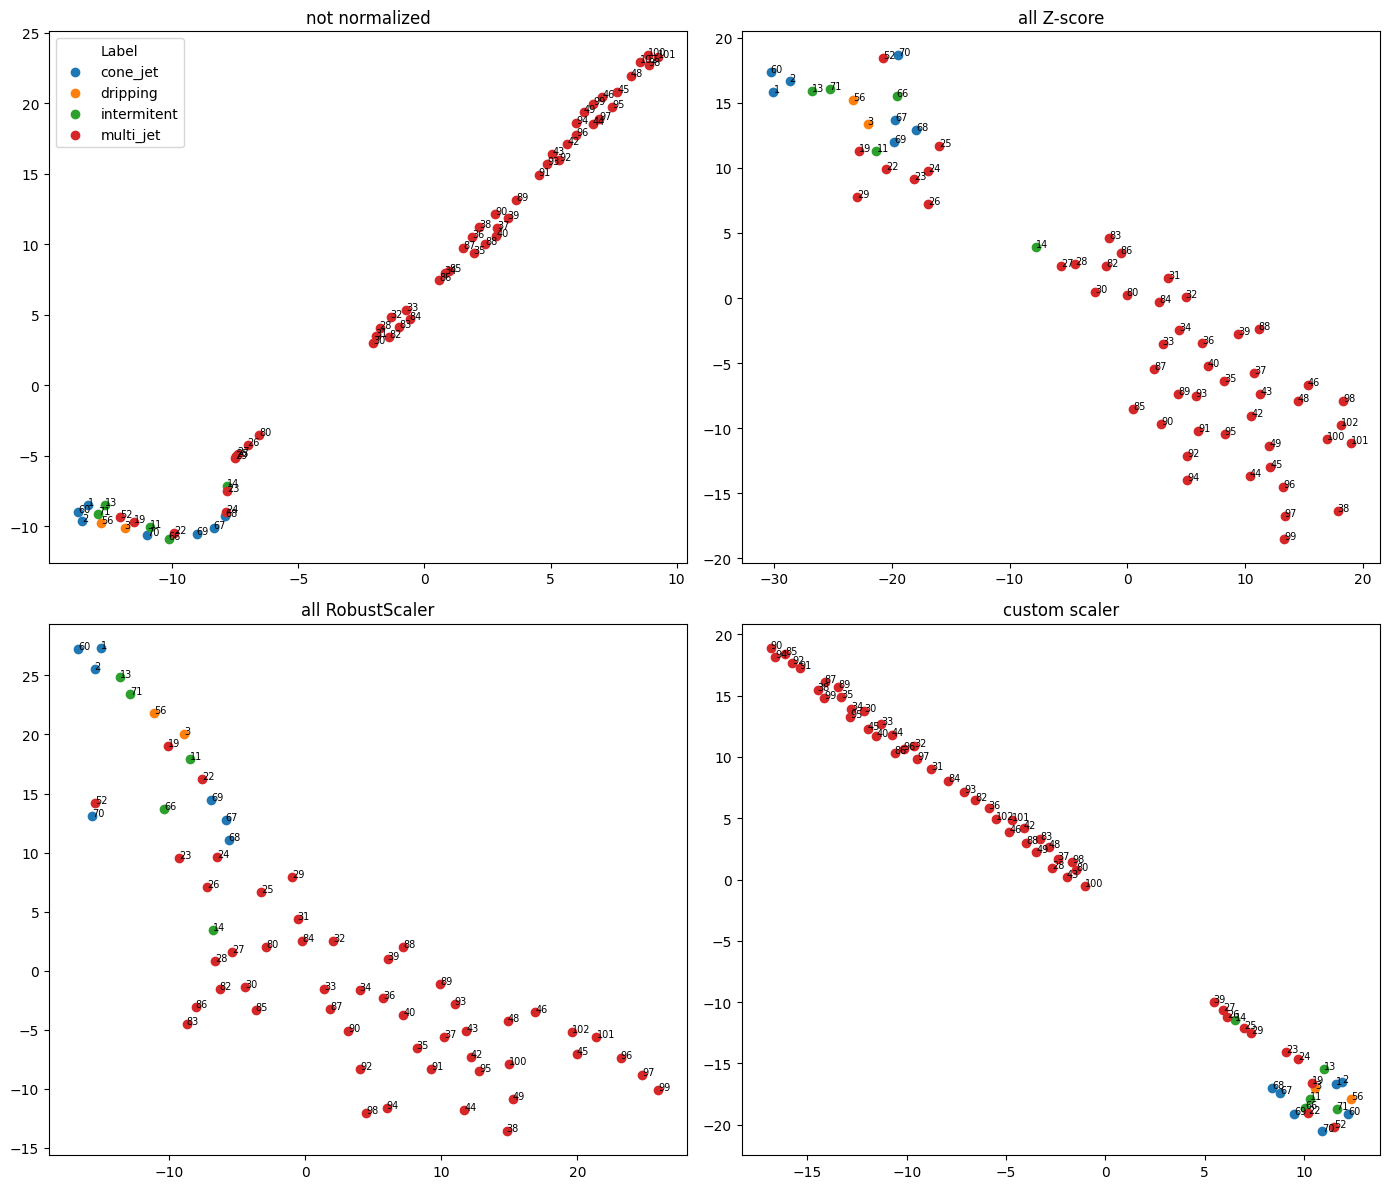

In [9]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, RobustScaler
import numpy as np



X = df[feature_cols].values
labels = df['label']
ids = df['sample_id']

# --- Different scalings ---
X_raw = X
X_zscore = StandardScaler().fit_transform(X)
X_robust = RobustScaler().fit_transform(X)

def run_tsne(X):
    return TSNE(n_components=2, perplexity=10, random_state=42).fit_transform(X)

embeddings = {
    "not normalized": run_tsne(X_raw),
    "all Z-score": run_tsne(X_zscore),
    "all RobustScaler": run_tsne(X_robust),
    "custom scaler": run_tsne(X_scaled),
}

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (title, emb) in zip(axes, embeddings.items()):
    for lab in labels.unique():
        idx = labels == lab
        ax.scatter(emb[idx, 0], emb[idx, 1], label=str(lab))

    # annotate
    for i, txt in enumerate(ids):
        ax.text(emb[i, 0], emb[i, 1], str(txt), fontsize=7)

    ax.set_title(title)

axes[0].legend(title="Label")
plt.tight_layout()
plt.show()